In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
import os

print(os.path.exists("../data/processed/ipl_cleaned.csv"))

True


In [4]:
import os

size = os.path.getsize("../data/processed/ipl_cleaned.csv")
print(size)

74956209


In [5]:
df = pd.read_csv("../data/processed/ipl_cleaned.csv", nrows=5)

df.head()

,match_id,season,date,city,venue,team1,team2,toss_winner,toss_decision,winner,...,current_score,wickets_down,balls_remaining,wickets_remaining,current_run_rate,required_run_rate,target_score,wicket_kind,player_out,fielder
0,335982,2007/08,2008-04-18,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,...,1,0,119,10,6.0,NaN,NaN,NaN,NaN,NaN
1,335982,2007/08,2008-04-18,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,...,1,0,118,10,3.0,NaN,NaN,NaN,NaN,NaN
2,335982,2007/08,2008-04-18,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,...,2,0,118,10,6.0,NaN,NaN,NaN,NaN,NaN
3,335982,2007/08,2008-04-18,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,...,2,0,117,10,4.0,NaN,NaN,NaN,NaN,NaN
4,335982,2007/08,2008-04-18,Bangalore,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,...,2,0,116,10,3.0,NaN,NaN,NaN,NaN,NaN


In [6]:
venue_matches = df["venue"].value_counts()

venue_matches.head(10)

venue
M Chinnaswamy Stadium    5
Name: count, dtype: int64

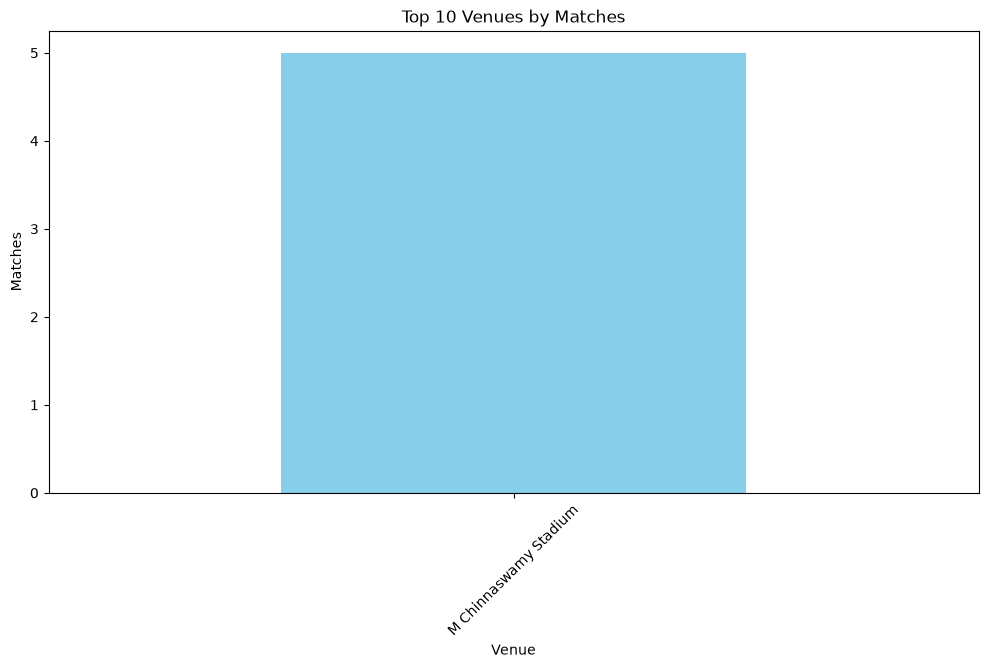

In [7]:
plt.figure(figsize=(12,6))

venue_matches.head(10).plot(kind="bar", color="skyblue")

plt.title("Top 10 Venues by Matches")
plt.xlabel("Venue")
plt.ylabel("Matches")

plt.xticks(rotation=45)

plt.show()

In [8]:
avg_runs = (
    df.groupby("venue")["runs_scored"]
      .mean()
      .sort_values(ascending=False)
)

avg_runs.head(10)

venue
M Chinnaswamy Stadium    0.0
Name: runs_scored, dtype: float64

In [10]:
avg_runs = (
    df.groupby("venue")["runs_scored"]
      .mean()
      .sort_values(ascending=False)
)

avg_runs.head(10)

venue
M Chinnaswamy Stadium    0.0
Name: runs_scored, dtype: float64

In [13]:
venue_wickets = (
    df[df["player_out"].notna()]
    .groupby("venue")["player_out"]
    .count()
    .sort_values(ascending=False)
)

venue_wickets.head(10)

Series([], Name: player_out, dtype: int64)

In [16]:
venue_wickets = (
    df[df["player_out"].notna()]
    .groupby("venue")["player_out"]
    .count()
    .sort_values(ascending=False)
)

venue_wickets.head()

Series([], Name: player_out, dtype: int64)

In [17]:
venue_summary = pd.DataFrame({
    "Matches": venue_matches,
    "Average Runs": avg_runs,
    "Wickets": venue_wickets
}).fillna(0)

venue_summary.head()

,Matches,Average Runs,Wickets
venue,,,
M Chinnaswamy Stadium,5,0.0,0.0


In [18]:
venue_summary.to_csv("reports/venue_analysis.csv")

print("Venue Analysis Completed Successfully")

Venue Analysis Completed Successfully
